In [52]:
import numpy as np
import pandas as pd
from pathlib import Path

import matplotlib.pyplot as plt
import seaborn as sns

from som_model import GeneralCLASSOM

LOAD CSV FILE WITH TRAIN DATA
check shape and featuresname

In [66]:
df = pd.read_csv("../data/features_full_file_SOM_ScrRate.csv")
df_som = df.copy()
print("Shape:", df.shape)
print("\nColumns:")
print(df_som.columns)

print("\nDescribe:")
print(df_som.describe())

Shape: (108428, 6)

Columns:
Index(['HR', 'HRV_RMSSD', 'HRV_SDNN', 'SCR_Rate', 'EDA_Tonic_log',
       'EDA_Phasic_log'],
      dtype='str')

Describe:
                  HR      HRV_RMSSD       HRV_SDNN       SCR_Rate  \
count  108428.000000  108428.000000  108428.000000  108428.000000   
mean       79.283488      54.870827      63.313658       0.026782   
std        11.097128      22.455123      31.007067       0.039017   
min        52.596467       6.833602       9.829522       0.000000   
25%        71.396398      36.801615      41.726876       0.000000   
50%        78.343750      53.488340      56.681599       0.000000   
75%        86.078315      71.789239      77.275378       0.032790   
max       141.215822     133.037076     200.000000       0.200000   

       EDA_Tonic_log  EDA_Phasic_log  
count  108428.000000   108428.000000  
mean        6.929523       -1.942847  
std         0.412408        1.545011  
min         6.000000       -4.000000  
25%         6.665002       -3.1

FUNCTION FOR TOPOGRAPIC_ERROR 

In [54]:
def topographic_error(som, data):

    error_count = 0

    for x in data:

        # avstånd till alla neuroner
        weights = som.get_weights()
        dists = np.linalg.norm(weights - x, axis=2)

        # hitta BMU och second BMU
        bmu_idx = np.unravel_index(np.argmin(dists), dists.shape)

        dists[bmu_idx] = np.inf
        second_bmu = np.unravel_index(np.argmin(dists), dists.shape)

        # kontrollera om de är grannar
        if max(abs(bmu_idx[0]-second_bmu[0]),
               abs(bmu_idx[1]-second_bmu[1])) > 1:
            error_count += 1

    return error_count / len(data)

CREATE SOM MODEL PARAMETERS

OUTPUT: SUMMARY OF DIFFERENT PARAMETERS

In [55]:
som_clas_200 = GeneralCLASSOM(

    x=30,
    y=30,
    input_len=6,

    sigma=6,
    learning_rate=0.1,

    random_seed=42
)

som_clas_200.get_summary()

{'x': 30,
 'y': 30,
 'input_len': 6,
 'sigma': 6,
 'learning_rate': 0.1,
 'decay_function': 'asymptotic_decay',
 'neighborhood_function': 'gaussian',
 'topology': 'rectangular',
 'activation_distance': 'euclidean',
 'sigma_decay_function': 'asymptotic_decay',
 'random_seed': 42}

TRAIN MODELL 

Change parameters

iterations:

mode

pca

In [67]:
som_clas_200.train(

   df_som,

    iterations=300000,
    mode="batch",

    use_pca=True,
    verbose=True
)

 [ 300000 / 300000 ] 100% - 0:00:00 left 
 quantization error: 0.20617912424812823
Training completed (300000 iterations)


SOM WEIGHTS MIN/MAX 

CHECK SO MAX/MIN SCALER WORKS 

In [68]:
print("SOM weights min/max:")
weights = som_clas_200.som.get_weights()
print(weights.min(), weights.max())

SOM weights min/max:
8.632084446060411e-11 0.9958296799249416


SOM NEURON ANALYSIS

1. Feature-wise variation
Each feature should show variation across the map.

2. Weight planes (component maps)
Each feature is visualized across the SOM grid.

3. Neuron variance
Measures how much each neuron varies across features.

4. Dead neurons
Neurons with very low variance

5. Weight distribution
Histogram of all weights

=== BASIC INFO ===
Shape: (30, 30, 6)
Global min: 8.632084446060411e-11
Global max: 0.9958296799249416
Global variance: 0.04862134306276849

=== FEATURE-WISE RANGE ===
Feature 0: min=0.133, max=0.482, var=0.0124
Feature 1: min=0.086, max=0.747, var=0.0154
Feature 2: min=0.090, max=0.909, var=0.0312
Feature 3: min=0.000, max=0.617, var=0.0190
Feature 4: min=0.301, max=0.975, var=0.0190
Feature 5: min=0.013, max=0.996, var=0.0769

=== VISUALIZING WEIGHT PLANES ===


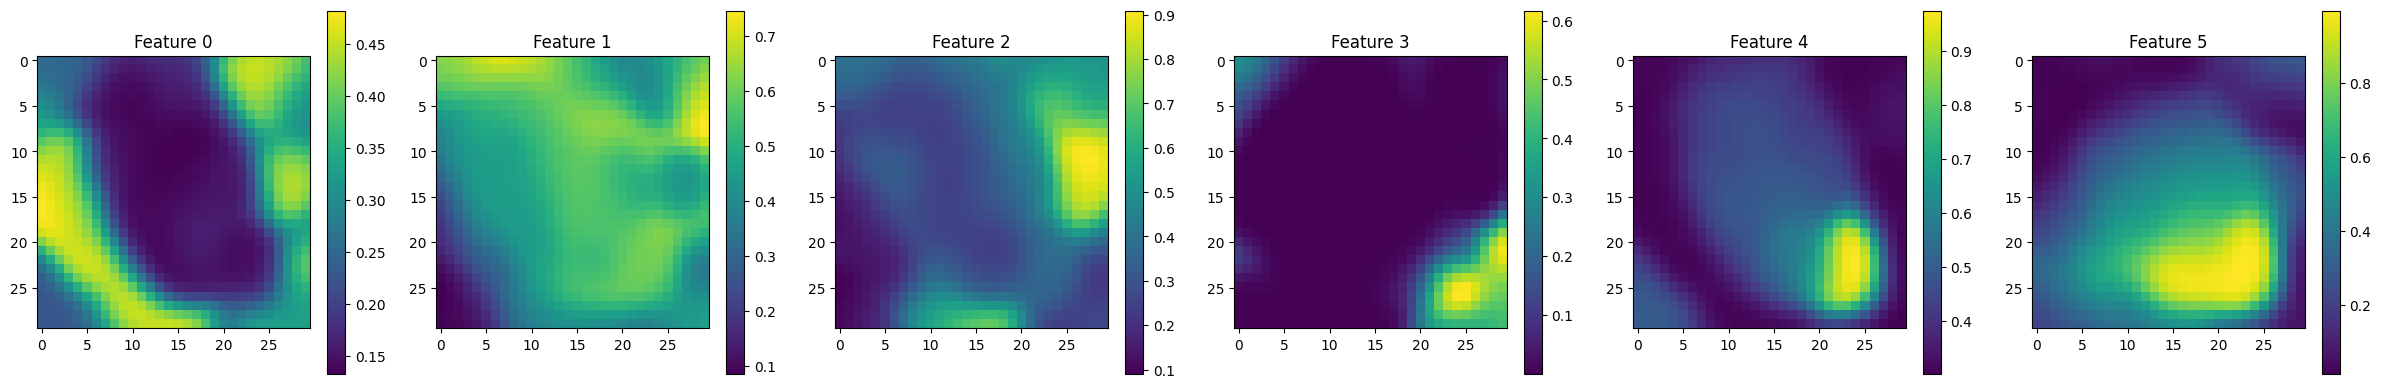


=== NEURON VARIATION ===
Neuron variance stats:
min: 0.0025735489712402954
max: 0.11890262201422853
mean: 0.042394147916858776


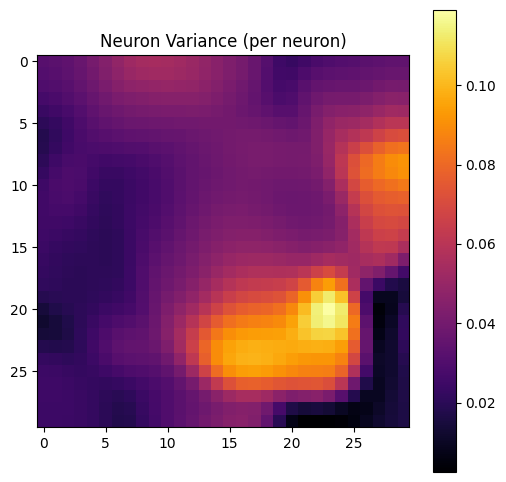


=== LOW VARIANCE NEURONS ===
Low-variance neurons (<5th percentile): 45


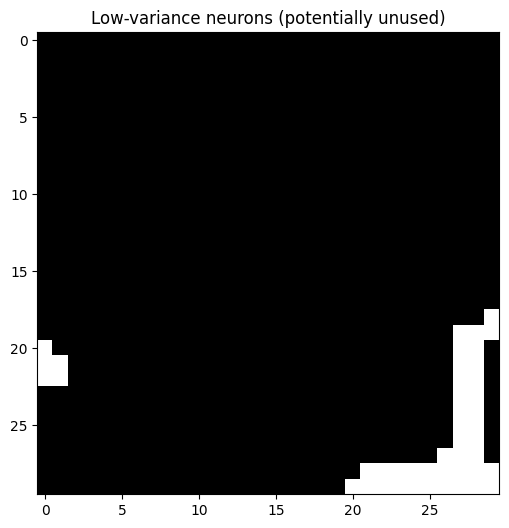


=== WEIGHT DISTRIBUTION ===


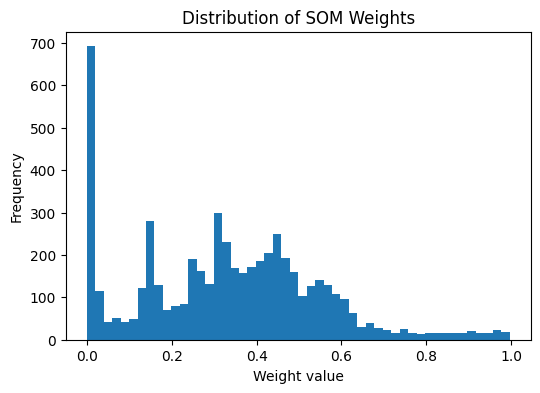

In [69]:
# === Hämta weights ===
weights = som_clas_200.som.get_weights()  # shape: (x, y, features)

print("=== BASIC INFO ===")
print("Shape:", weights.shape)
print("Global min:", weights.min())
print("Global max:", weights.max())
print("Global variance:", np.var(weights))

# =========================================
# 1. FEATURE-WISE ANALYS 
# =========================================
print("\n=== FEATURE-WISE RANGE ===")

n_features = weights.shape[2]

for i in range(n_features):
    w = weights[:, :, i]
    print(f"Feature {i}: min={w.min():.3f}, max={w.max():.3f}, var={np.var(w):.4f}")

# =========================================
# 2. VISUALISERA WEIGHT PLANES
# =========================================
print("\n=== VISUALIZING WEIGHT PLANES ===")

fig, axes = plt.subplots(1, n_features, figsize=(4*n_features, 4))

for i in range(n_features):
    ax = axes[i] if n_features > 1 else axes
    im = ax.imshow(weights[:, :, i], cmap="viridis")
    ax.set_title(f"Feature {i}")
    plt.colorbar(im, ax=ax)

plt.tight_layout()
plt.show()

# =========================================
# 3. NEURON VARIATION 
# =========================================
print("\n=== NEURON VARIATION ===")

# variation per neuron (över features)
neuron_variance = np.var(weights, axis=2)

print("Neuron variance stats:")
print("min:", neuron_variance.min())
print("max:", neuron_variance.max())
print("mean:", neuron_variance.mean())

plt.figure(figsize=(6,6))
plt.imshow(neuron_variance, cmap="inferno")
plt.colorbar()
plt.title("Neuron Variance (per neuron)")
plt.show()

# =========================================
# 4. DEAD / LOW-ACTIVITY NEURONS
# =========================================
print("\n=== LOW VARIANCE NEURONS ===")

threshold = np.percentile(neuron_variance, 5)

dead_mask = neuron_variance < threshold
num_dead = np.sum(dead_mask)

print(f"Low-variance neurons (<5th percentile): {num_dead}")

plt.figure(figsize=(6,6))
plt.imshow(dead_mask, cmap="gray")
plt.title("Low-variance neurons (potentially unused)")
plt.show()

# =========================================
# 5. WEIGHT DISTRIBUTION
# =========================================
print("\n=== WEIGHT DISTRIBUTION ===")

plt.figure(figsize=(6,4))
plt.hist(weights.flatten(), bins=50)
plt.title("Distribution of SOM Weights")
plt.xlabel("Weight value")
plt.ylabel("Frequency")
plt.show()

In [79]:
scaled_train = som_clas_200.scaler.transform(df_som)

qe = som_clas_200.som.quantization_error(scaled_train)

te = topographic_error(
    som_clas_200.som,
    scaled_train
)

print("Quantization Error:", qe)
print("Topographic Error:", te)

Quantization Error: 0.20617912424812823
Topographic Error: 0.062253292507470394


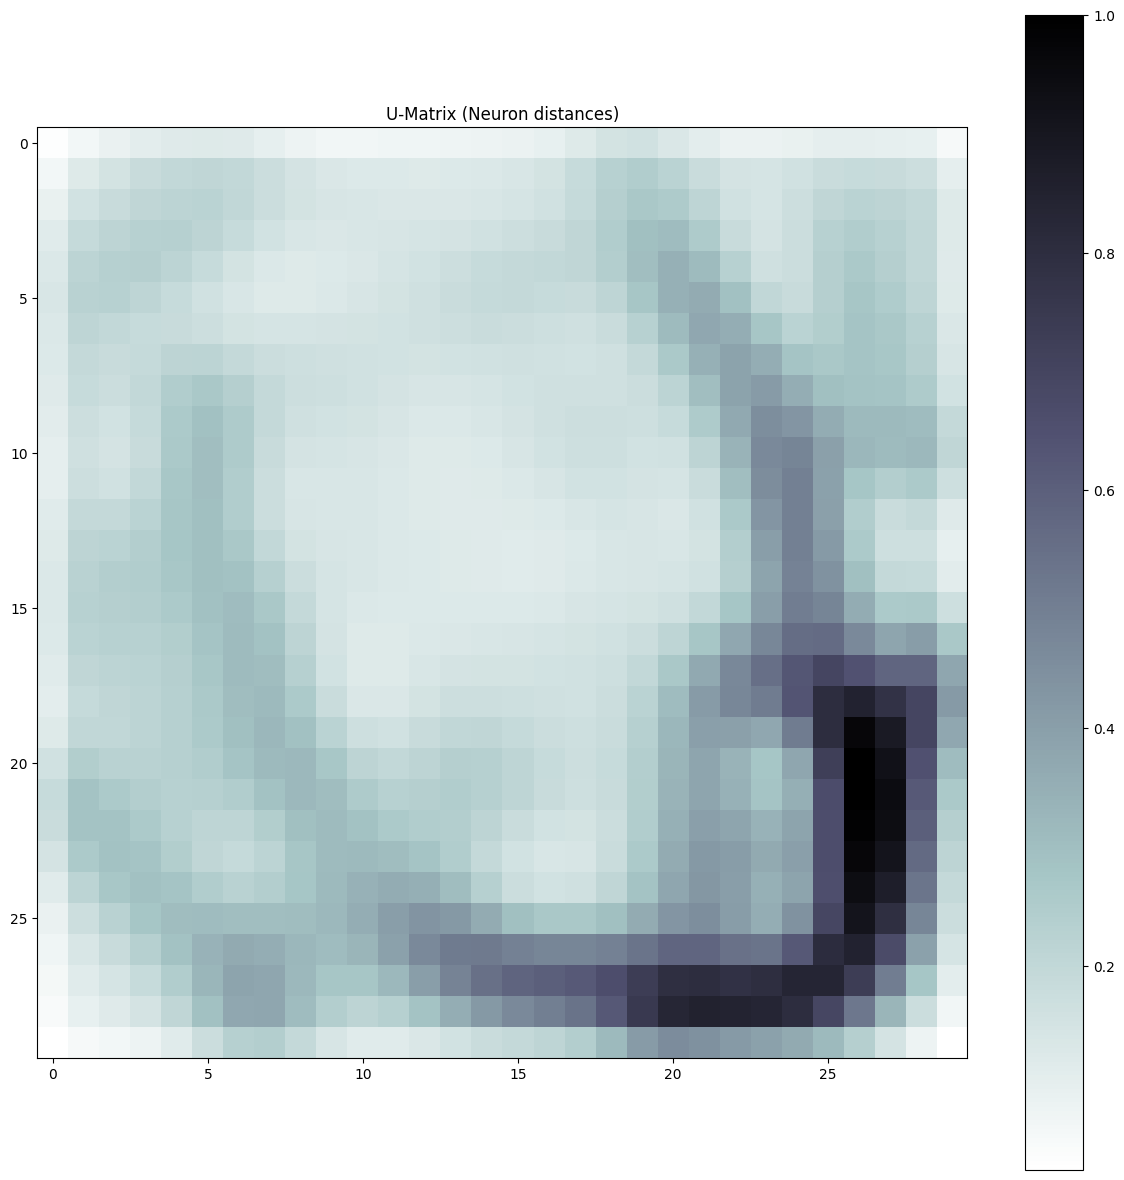

In [71]:
u_matrix = som_clas_200.get_u_matrix()

plt.figure(figsize=(15,15))
plt.imshow(u_matrix, cmap="bone_r")
plt.colorbar()
plt.title("U-Matrix (Neuron distances)")
plt.show()

In [72]:
cluster_map = som_clas_200.create_clusters(
    data=df_som,
    n_clusters=3,
    method="density"
)

In [73]:
from sklearn.metrics import silhouette_score
import numpy as np

# 1. Skala datan (samma som SOM använde)
X_scaled = som_clas_200.scaler.transform(df_som)

# 2. Få cluster labels för varje datapunkt
labels = som_clas_200.predict_cluster(df_som)

# 3. Beräkna silhouette score
score = silhouette_score(X_scaled, labels)

print("Silhouette Score:", score)



Silhouette Score: 0.1820402635704615


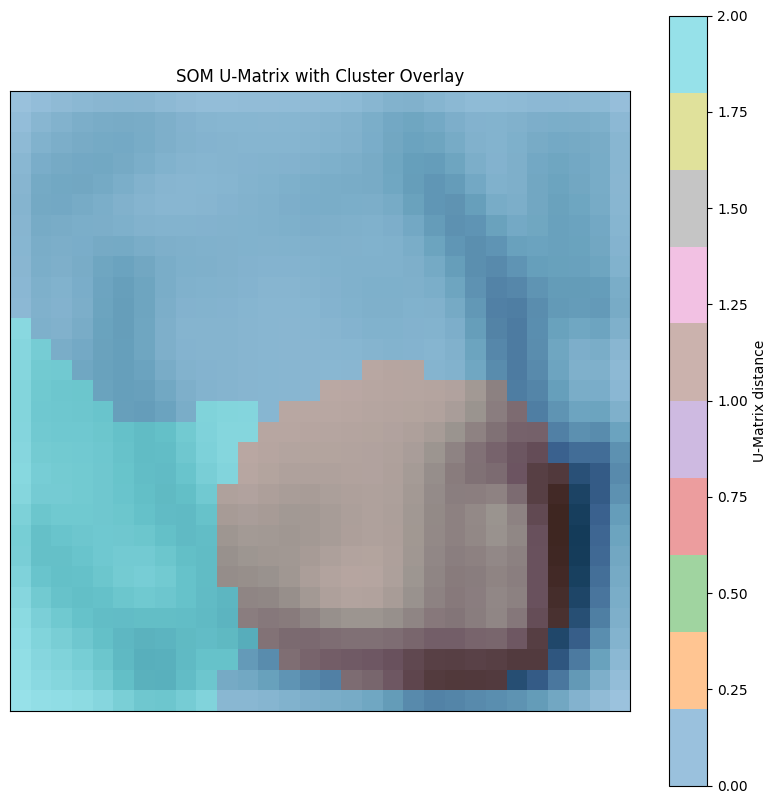

In [74]:
plt.figure(figsize=(10,10))

plt.imshow(u_matrix, cmap="bone_r")

plt.imshow(
    cluster_map,
    cmap="tab10",
    alpha=0.45
)

plt.colorbar(label="U-Matrix distance")

plt.title("SOM U-Matrix with Cluster Overlay")

plt.xticks([])
plt.yticks([])

plt.show()

**SOM Analysis Panel**

1. U-Matrix (Unified Distance Matrix)
The U-Matrix visualizes the average distance between neighboring neurons.

- Light areas → **similar neurons (clusters)**
- Dark areas → **large distances (cluster boundaries)**

2. Hit Map **(Activation Map)**
The hit map shows how many data samples are mapped to each neuron.

3. Cluster Map
Displays clustering results applied to SOM neurons (here using density-aware KMeans).

4. U-Matrix + Cluster Overlay
Combines structural information (U-Matrix) with clustering.

5. Feature Maps (Component Planes)

Each feature is visualized across the SOM grid using neuron weights.

Each feature map shows how that variable varies across the SOM:

- Smooth gradients → structured relationship  
- Sharp transitions → strong separation between regions  
- Uniform areas → low influence of that feature  

Feature maps help identify:

- Which variables drive clustering  
- Relationships between physiological signals  
- Correlations (e.g., HR vs HRV)  
- Regions of high/low activation  

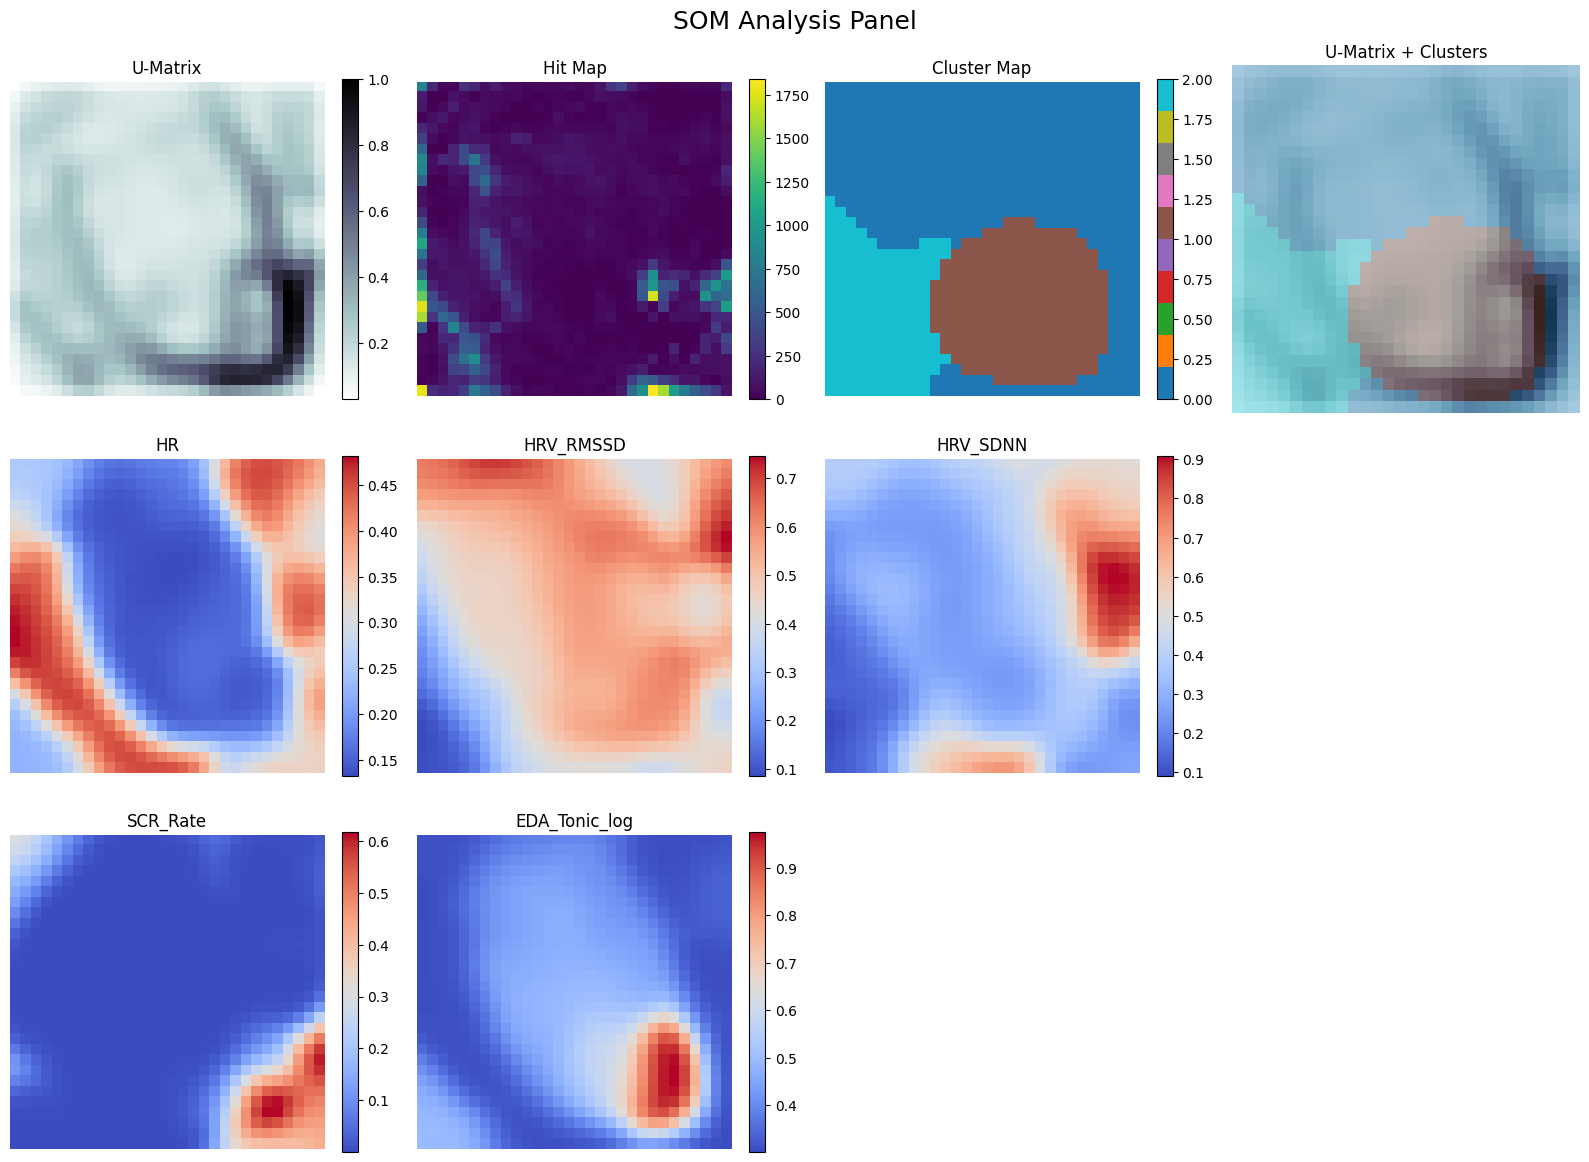

In [75]:
# ===== COMPLETE SOM VISUALIZATION PANEL =====

import matplotlib.pyplot as plt
import numpy as np

# ---- Prepare data ----
scaled_data = som_clas_200.scaler.transform(df_som)

u_matrix = som_clas_200.get_u_matrix()

hits = som_clas_200.som.activation_response(scaled_data)

cluster_map = som_clas_200.create_clusters(
    data=df_som,
    n_clusters=3,
    method="density"
)

weights = som_clas_200.som.get_weights()

feature_names = [
    "HR",
    "HRV_RMSSD",
    "HRV_SDNN",
    "SCR_Rate",
    "EDA_Tonic_log",
    "EDA_Phasic_log"
]

# ---- Figure layout ----
fig = plt.figure(figsize=(16,12))

grid = fig.add_gridspec(3,4)

# ---- U-Matrix ----
ax1 = fig.add_subplot(grid[0,0])
im = ax1.imshow(u_matrix, cmap="bone_r")
ax1.set_title("U-Matrix")
ax1.axis("off")
plt.colorbar(im, ax=ax1, fraction=0.046)

# ---- Hit Map ----
ax2 = fig.add_subplot(grid[0,1])
im = ax2.imshow(hits, cmap="viridis")
ax2.set_title("Hit Map")
ax2.axis("off")
plt.colorbar(im, ax=ax2, fraction=0.046)

# ---- Cluster Map ----
ax3 = fig.add_subplot(grid[0,2])
im = ax3.imshow(cluster_map, cmap="tab10")
ax3.set_title("Cluster Map")
ax3.axis("off")
plt.colorbar(im, ax=ax3, fraction=0.046)

# ---- U-Matrix + Cluster Overlay ----
ax4 = fig.add_subplot(grid[0,3])
ax4.imshow(u_matrix, cmap="bone_r")
ax4.imshow(cluster_map, cmap="tab10", alpha=0.4)
ax4.set_title("U-Matrix + Clusters")
ax4.axis("off")

# ---- Feature Maps ----
for i in range(5):

    row = 1 + i // 3
    col = i % 3

    ax = fig.add_subplot(grid[row, col])

    im = ax.imshow(weights[:,:,i], cmap="coolwarm")
    ax.set_title(feature_names[i])
    ax.axis("off")

    plt.colorbar(im, ax=ax, fraction=0.046)

# ---- Layout ----
plt.suptitle("SOM Analysis Panel", fontsize=18)
plt.tight_layout()
plt.show()

In [76]:
df["cluster"] = som_clas_200.predict_cluster(df_som)

cluster_profiles = df.groupby("cluster").mean()

cluster_profiles

print("Counts:")
print(df["cluster"].value_counts())

print("\nMeans:")
print(df.groupby("cluster").mean())

print("\nStd:")
print(df.groupby("cluster").std())




Counts:
cluster
0    53382
2    39026
1    16020
Name: count, dtype: int64

Means:
                HR  HRV_RMSSD   HRV_SDNN  SCR_Rate  EDA_Tonic_log  \
cluster                                                             
0        76.616917  66.091868  76.475010  0.040094       6.793305   
1        74.924016  64.081836  70.750532  0.019781       7.576507   
2        84.720520  35.740966  42.258001  0.011448       6.850267   

         EDA_Phasic_log  
cluster                  
0             -2.730329  
1              0.591510  
2             -1.906026  

Std:
                HR  HRV_RMSSD   HRV_SDNN  SCR_Rate  EDA_Tonic_log  \
cluster                                                             
0         9.526202  18.314258  31.403456  0.046124       0.261335   
1         9.989529  20.957696  28.428728  0.034896       0.483542   
2        11.400223  13.742034  16.957255  0.017945       0.282239   

         EDA_Phasic_log  
cluster                  
0              1.018124  
1          

In [ ]:
cluster_profiles.describe()

In [ ]:
print("---- Scaling info ----")

print("Min:", scaled_data.min(axis=0))
print("Max:", scaled_data.max(axis=0))
print("----------------------")


=== MEAN PER CLUSTER ===


,HR,HRV_RMSSD,HRV_SDNN,SCR_Rate,EDA_Tonic_log,EDA_Phasic_log
cluster,,,,,,
0,76.616917,66.091868,76.475010,0.040094,6.793305,-2.730329
1,74.924016,64.081836,70.750532,0.019781,7.576507,0.591510
2,84.720520,35.740966,42.258001,0.011448,6.850267,-1.906026



=== STD PER CLUSTER ===


,HR,HRV_RMSSD,HRV_SDNN,SCR_Rate,EDA_Tonic_log,EDA_Phasic_log
cluster,,,,,,
0,9.526202,18.314258,31.403456,0.046124,0.261335,1.018124
1,9.989529,20.957696,28.428728,0.034896,0.483542,1.098631
2,11.400223,13.742034,16.957255,0.017945,0.282239,1.110210



=== FEATURE IMPORTANCE (normalized difference) ===


,HR,HRV_RMSSD,HRV_SDNN,SCR_Rate,EDA_Tonic_log,EDA_Phasic_log
0,0.240294,0.499710,0.424463,0.341176,0.330300,0.509694
1,0.392847,0.410196,0.239844,0.179444,1.568794,1.640349
2,0.489949,0.851915,0.679060,0.393019,0.192180,0.023832


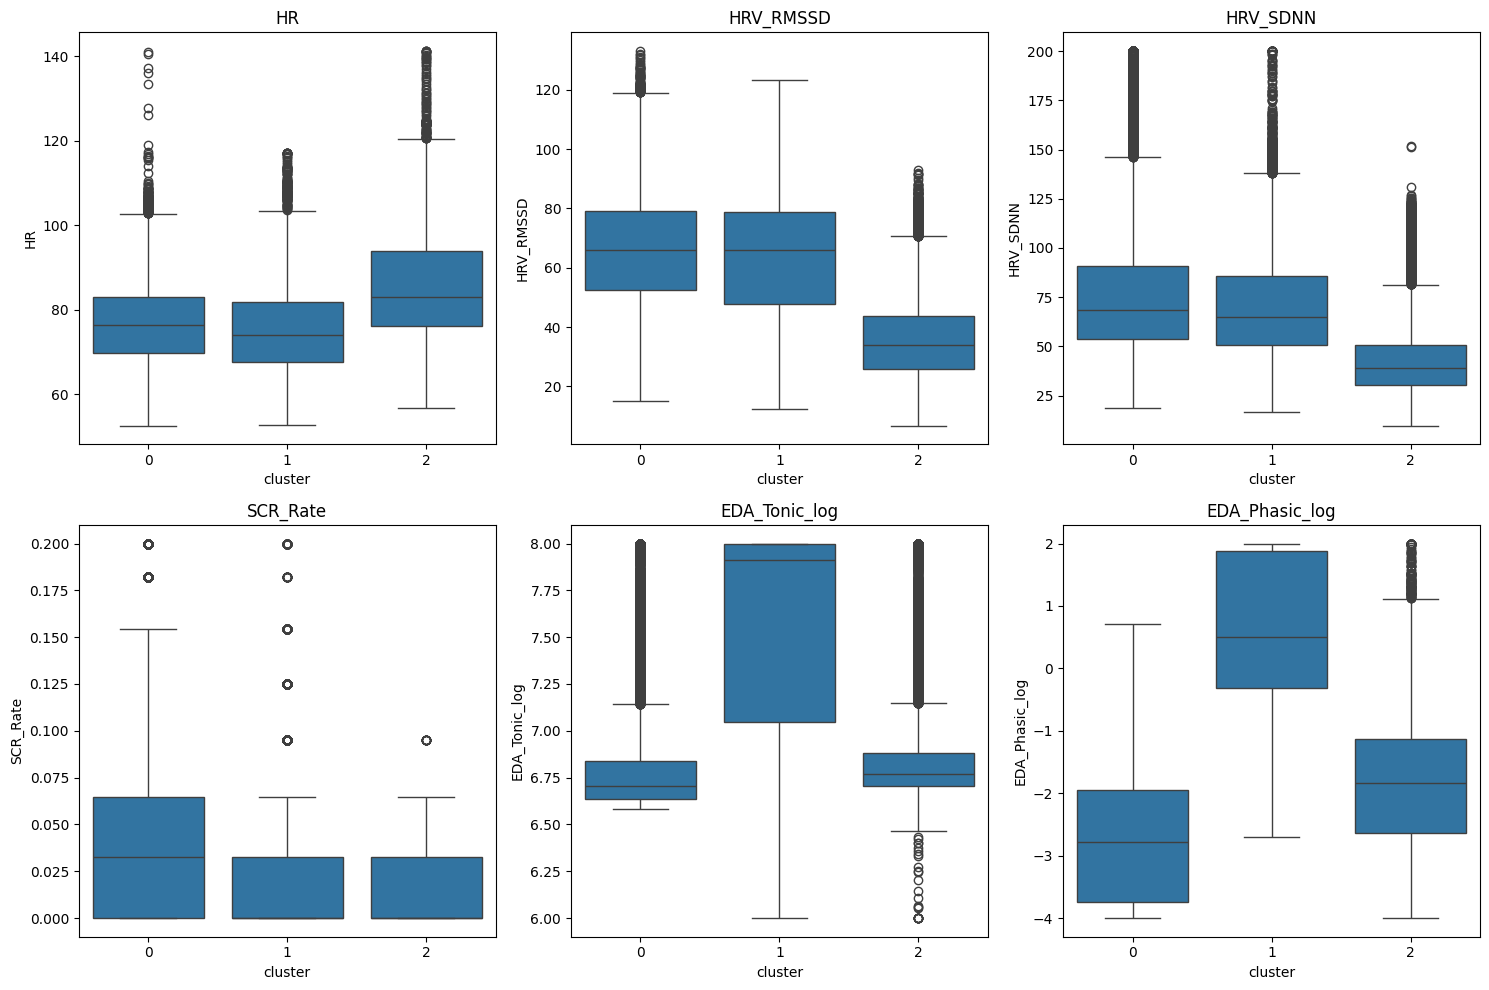


=== COHEN'S D BETWEEN CLUSTERS ===

Cluster 0 vs 1
HR: 0.17
HRV_RMSSD: 0.10
HRV_SDNN: 0.19
SCR_Rate: 0.50
EDA_Tonic_log: -2.02
EDA_Phasic_log: -3.14

Cluster 0 vs 2
HR: -0.77
HRV_RMSSD: 1.87
HRV_SDNN: 1.36
SCR_Rate: 0.82
EDA_Tonic_log: -0.21
EDA_Phasic_log: -0.77

Cluster 1 vs 2
HR: -0.91
HRV_RMSSD: 1.60
HRV_SDNN: 1.22
SCR_Rate: 0.30
EDA_Tonic_log: 1.83
EDA_Phasic_log: 2.26


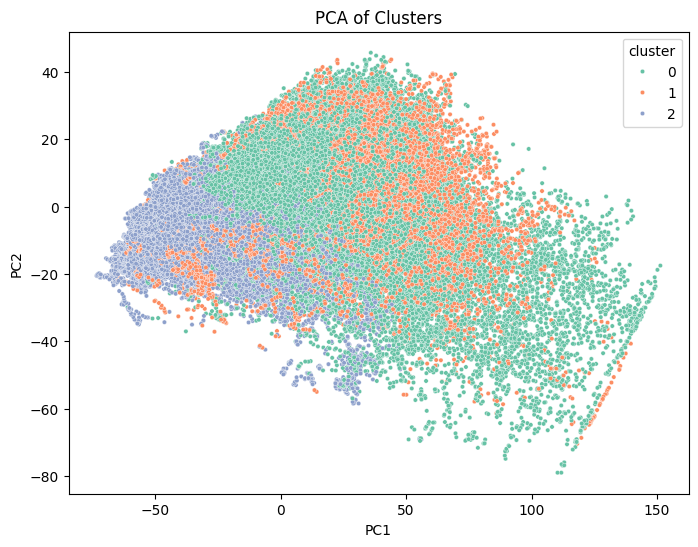

In [78]:
# ================================
# FULL CLUSTER ANALYSIS CELL
# ================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA
from itertools import combinations

# -------------------------
# 1. DATAFRAME
# -------------------------
feature_names = ["HR", "HRV_RMSSD", "HRV_SDNN", "SCR_Rate", "EDA_Tonic_log", "EDA_Phasic_log"]

df = pd.DataFrame(df_som, columns=feature_names)
df["cluster"] = som_clas_200.predict_cluster(df_som)

# -------------------------
# 2. BASIC STATS
# -------------------------
print("\n=== MEAN PER CLUSTER ===")
display(df.groupby("cluster").mean())

print("\n=== STD PER CLUSTER ===")
display(df.groupby("cluster").std())

# -------------------------
# 3. FEATURE IMPORTANCE
# -------------------------
print("\n=== FEATURE IMPORTANCE (normalized difference) ===")

global_mean = df[feature_names].mean()
global_std = df[feature_names].std()

importance = []

for c in sorted(df["cluster"].unique()):
    diff = abs(df[df.cluster == c][feature_names].mean() - global_mean) / global_std
    importance.append(diff)

importance_df = pd.DataFrame(importance, index=sorted(df["cluster"].unique()))
display(importance_df)

# -------------------------
# 4. BOXPLOTS
# -------------------------
plt.figure(figsize=(15, 10))
for i, col in enumerate(feature_names):
    plt.subplot(2, 3, i+1)
    sns.boxplot(x="cluster", y=col, data=df)
    plt.title(col)
plt.tight_layout()
plt.show()

# -------------------------
# 5. COHEN'S D (EFFECT SIZE)
# -------------------------
def cohens_d(x, y):
    return (np.mean(x) - np.mean(y)) / np.sqrt((np.std(x)**2 + np.std(y)**2) / 2)

print("\n=== COHEN'S D BETWEEN CLUSTERS ===")

for (c1, c2) in combinations(sorted(df.cluster.unique()), 2):
    print(f"\nCluster {c1} vs {c2}")
    for col in feature_names:
        d = cohens_d(df[df.cluster==c1][col], df[df.cluster==c2][col])
        print(f"{col}: {d:.2f}")

# -------------------------
# 6. PCA VISUALIZATION
# -------------------------
pca = PCA(n_components=2)
X_pca = pca.fit_transform(df[feature_names])

plt.figure(figsize=(8,6))
sns.scatterplot(x=X_pca[:,0], y=X_pca[:,1], hue=df["cluster"], palette="Set2", s=10)
plt.title("PCA of Clusters")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.show()



In [ ]:
# ================================
# FEATURE RANKING PER CLUSTER
# ================================

import pandas as pd
import numpy as np

feature_names = ["HR", "HRV_RMSSD", "HRV_SDNN","SCR_Count", "EDA_Tonic_log", "EDA_Phasic_log"]

# Global statistik
global_mean = df[feature_names].mean()
global_std = df[feature_names].std()

cluster_profiles = {}
ranking_rows = []

for c in sorted(df["cluster"].unique()):
    cluster_mean = df[df.cluster == c][feature_names].mean()
    
    # Normaliserad skillnad (importance score)
    importance = (cluster_mean - global_mean) / global_std
    
    # Absolut värde för ranking
    importance_abs = importance.abs().sort_values(ascending=False)
    
    # Spara topp-features
    top_features = importance_abs.index.tolist()
    
    for i, feat in enumerate(top_features):
        ranking_rows.append({
            "Cluster": c,
            "Rank": i+1,
            "Feature": feat,
            "Importance": importance[feat],
            "Abs Importance": importance_abs[feat]
        })

ranking_df = pd.DataFrame(ranking_rows)

# Visa topp 3 per kluster
print("\n=== TOP FEATURES PER CLUSTER ===")
display(ranking_df.groupby("Cluster").head(3))

# -------------------------
# BONUS: Pivot-tabell (snygg för rapport)
# -------------------------
pivot_table = ranking_df.pivot_table(
    index="Cluster",
    columns="Rank",
    values="Feature",
    aggfunc="first"
)

pivot_table.columns = [f"Rank {c}" for c in pivot_table.columns]

print("\n=== FEATURE RANKING TABLE ===")
display(pivot_table)

In [80]:
som_clas_200.set_cluster_labels({
    0: "Baseline/Recovery",
    1: "Cognitive Stress",
    2: "High Stress"
})


In [81]:
from pathlib import Path

MODEL_DIR = Path("../models")
MODEL_DIR.mkdir(exist_ok=True)

som_clas_200.export_to_c(filepath=MODEL_DIR / "som_model_200hz_ver7_full.h")



C header exported to: ..\models\som_model_200hz_ver7_full.h


In [82]:
from pathlib import Path

MODEL_DIR = Path("../models")
MODEL_DIR.mkdir(exist_ok=True)

model_path = MODEL_DIR / "som_model_200hz_ver7_full.pkl"

som_clas_200.save_model(model_path)

print("Model saved to:", model_path)

Model saved to: ..\models\som_model_200hz_ver7_full.pkl
